Best Parameters: {'clf': RandomForestClassifier(class_weight='balanced', random_state=42), 'clf__max_depth': 10, 'clf__n_estimators': 200}
Best F1 Score (CV): 0.6326811162186822

Classification Report:
              precision    recall  f1-score   support

           0     0.8840    0.7807    0.8291      1035
           1     0.5414    0.7166    0.6168       374

    accuracy                         0.7637      1409
   macro avg     0.7127    0.7486    0.7230      1409
weighted avg     0.7931    0.7637    0.7728      1409



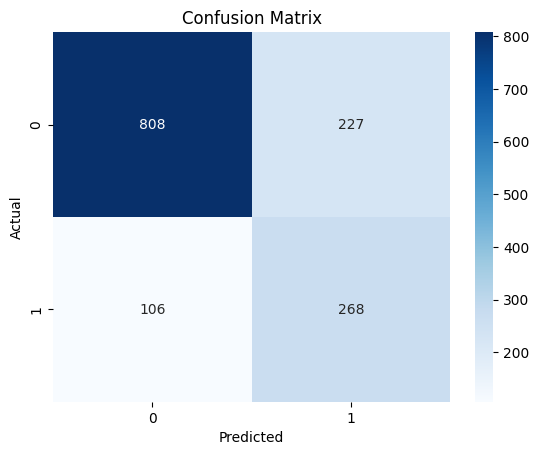

ROC-AUC Score: 0.8410


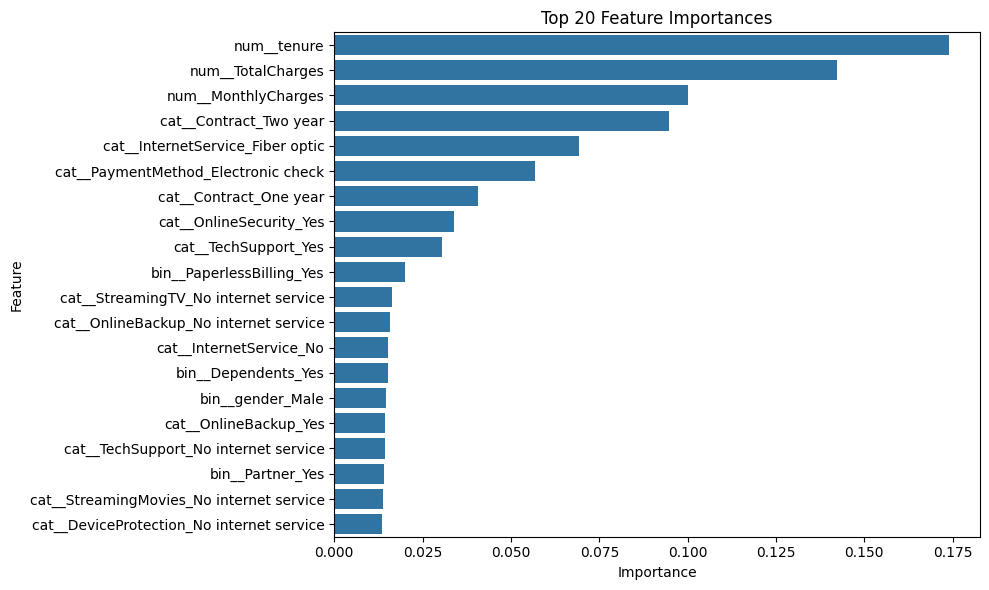

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and zipped as best_churn_model.zip


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer # Import SimpleImputer

import joblib
import zipfile
from google.colab import files

# -----------------------------
# 1️⃣ Load and preprocess data
# -----------------------------
customers = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

customers['TotalCharges'] = pd.to_numeric(customers['TotalCharges'], errors='coerce')
customers['SeniorCitizen'] = customers['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
customers.drop(columns=['customerID'], inplace=True)

X = customers.drop('Churn', axis=1)
y = customers['Churn'].map({'Yes':1, 'No':0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 2️⃣ Define column groups
# -----------------------------
binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaymentMethod']
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# -----------------------------
# 3️⃣ Preprocessing pipelines
# -----------------------------
binary_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='if_binary', dtype=int))
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', dtype=int))
])

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Add imputer
    ('scaler', MinMaxScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('bin', binary_pipeline, binary_cols),
    ('cat', categorical_pipeline, categorical_cols),
    ('num', numeric_pipeline, numeric_cols)
])

# Fit the preprocessor separately to get feature names
preprocessor.fit(X_train)


# -----------------------------
# 4️⃣ Pipeline with placeholder classifier
# -----------------------------
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# -----------------------------
# 5️⃣ Hyperparameter search space
# -----------------------------
search_space = [
    {'clf': [LogisticRegression(class_weight='balanced', max_iter=1000)],
     'clf__C': [0.01, 0.1, 1, 10],
     'clf__penalty': ['l2']},

    {'clf': [RandomForestClassifier(class_weight='balanced', random_state=42)],
     'clf__n_estimators': [50, 100, 200],
     'clf__max_depth': [None, 5, 10]},

    {'clf': [xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)],
     'clf__n_estimators': [50, 100, 200],
     'clf__max_depth': [3, 5, 7],
     'clf__learning_rate': [0.01, 0.1, 0.2]}
]

# -----------------------------
# 6️⃣ GridSearchCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=search_space,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", grid_search.best_score_)

# -----------------------------
# 7️⃣ Evaluate on test set
# -----------------------------
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model.named_steps['clf'], 'predict_proba') else None

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

if y_proba is not None:
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

# -----------------------------
# 8️⃣ Feature importances (tree models)
# -----------------------------
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    feature_names = preprocessor.get_feature_names_out()
    importances = best_model.named_steps['clf'].feature_importances_

    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_df.head(20))
    plt.title("Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 9️⃣ Save, zip, and download the model
# -----------------------------
model_filename = "best_churn_model.pkl"
joblib.dump(best_model, model_filename)

zip_filename = "best_churn_model.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write(model_filename)

files.download(zip_filename)
print(f"Model saved and zipped as {zip_filename}")